# Notebook 12: Explanatory — Safehouse Resources & Health Outcomes

## Problem Framing

**Business question:** How do monthly resource levels — counseling sessions,
home visits, incidents, and funding — relate to average health scores at each
safehouse?

**Who cares:** Program directors allocate limited budgets across safehouses.
Understanding which resource levers are most strongly associated with health
outcomes helps them make data-informed decisions.

**Model approach:** OLS regression on monthly panel data (9 safehouses × multiple
months). Health score is a composite measure (1–5 scale) capturing general
health, nutrition, and wellbeing.

**Causal disclaimer:** Observational panel data — associations, not proven causes.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

CSV_DIR = '../backend/HarborOfHope.API/Data/lighthouse_csv_v7/'
metrics = pd.read_csv(f'{CSV_DIR}safehouse_monthly_metrics.csv')
allocs = pd.read_csv(f'{CSV_DIR}donation_allocations.csv')
safehouses = pd.read_csv(f'{CSV_DIR}safehouses.csv')

print(f'Monthly metrics: {len(metrics)} rows')
print(f'Donation allocations: {len(allocs)} rows')
print(f'Safehouses: {len(safehouses)} rows')
metrics.head()

Monthly metrics: 450 rows
Donation allocations: 521 rows
Safehouses: 9 rows


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0,NaN
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,NaN
2,3,1,2023-03-01,2023-03-31,10,56.30,3.03,1,0,0,NaN
3,4,1,2023-04-01,2023-04-30,10,51.90,3.07,5,4,1,NaN
4,5,1,2023-05-01,2023-05-31,10,51.25,3.17,0,2,0,NaN


## Section 2 — Data Preparation & EDA

In [11]:
# Pivot wellbeing funding per safehouse-month
alloc = allocs.copy()
alloc['allocation_date'] = pd.to_datetime(alloc['allocation_date'])
alloc['ym'] = alloc['allocation_date'].dt.to_period('M').astype(str)

wellbeing = alloc[alloc['program_area'] == 'Wellbeing'].groupby(
    ['safehouse_id', 'ym']
)['amount_allocated'].sum().reset_index().rename(columns={'amount_allocated': 'wellbeing_funding'})

met = metrics.copy()
met['month_start'] = pd.to_datetime(met['month_start'])
met['ym'] = met['month_start'].dt.to_period('M').astype(str)
df = met.merge(wellbeing, on=['safehouse_id', 'ym'], how='left')
df['wellbeing_funding'] = df['wellbeing_funding'].fillna(0)
df = df.merge(safehouses[['safehouse_id', 'capacity_girls']], on='safehouse_id', how='left')

df['avg_health_score'] = pd.to_numeric(df['avg_health_score'], errors='coerce')
df = df.dropna(subset=['avg_health_score'])
print(f'Panel dataset: {len(df)} safehouse-months with health data')

Panel dataset: 253 safehouse-months with health data


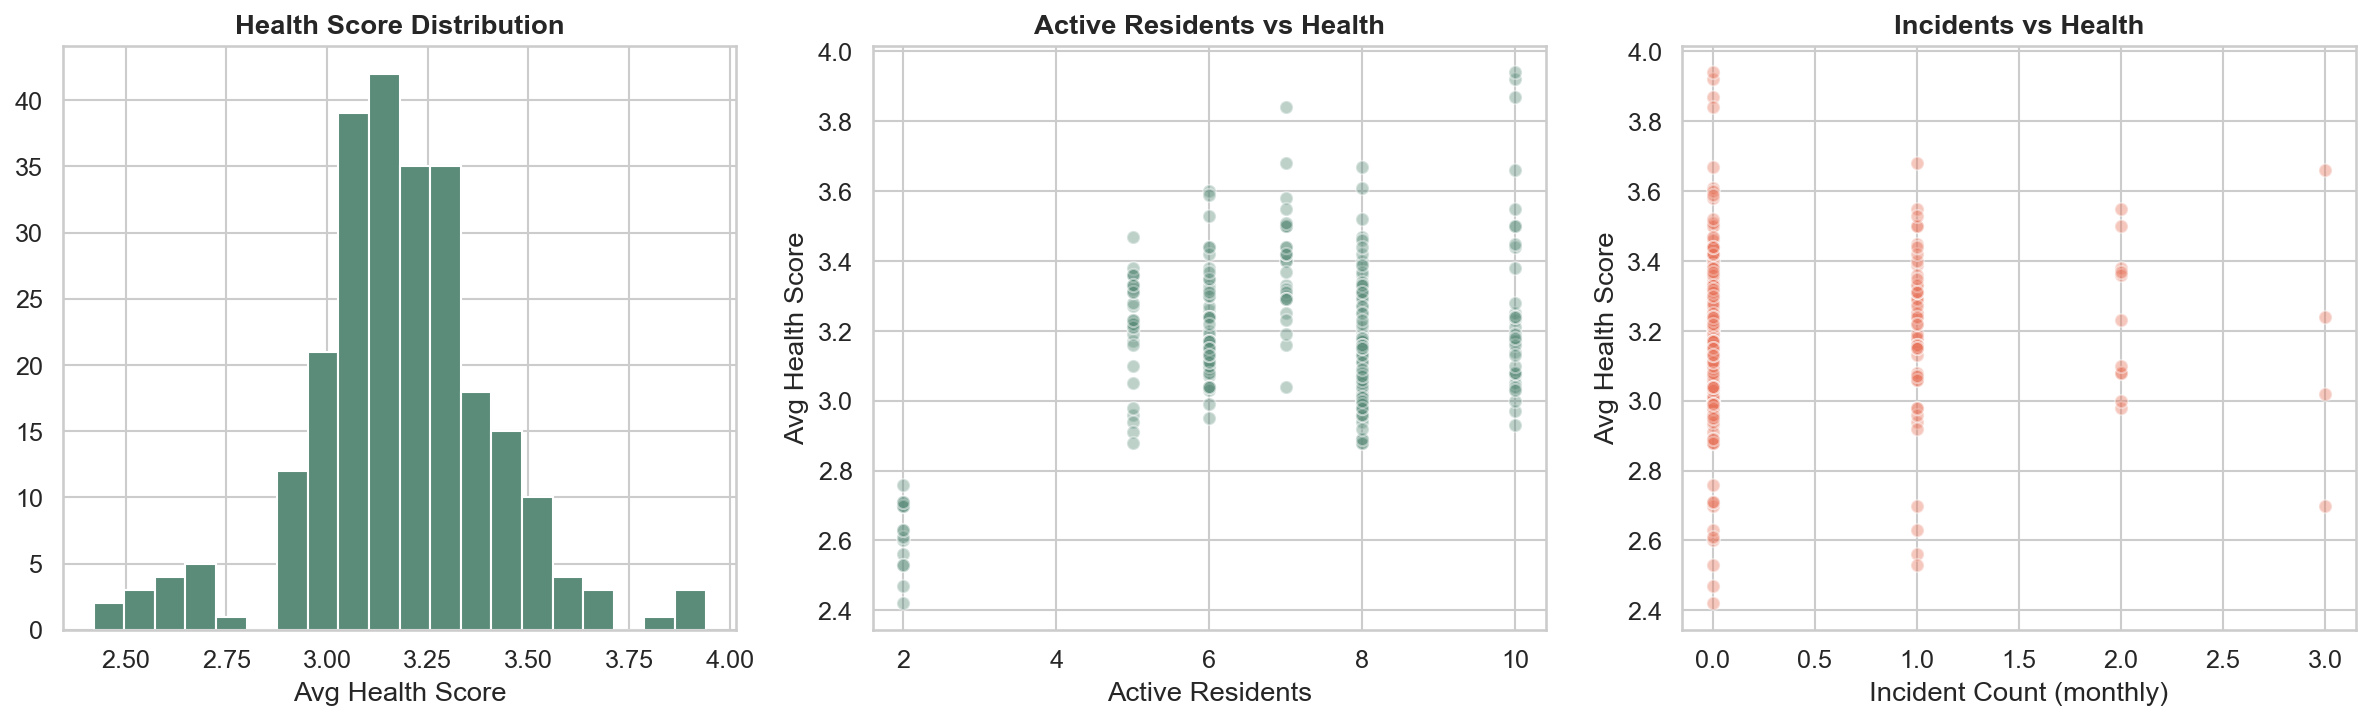

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Health score distribution
df['avg_health_score'].hist(ax=axes[0], bins=20, color='#5B8C7A', edgecolor='white')
axes[0].set_title('Health Score Distribution', fontweight='bold')
axes[0].set_xlabel('Avg Health Score')

# Health vs active residents
axes[1].scatter(df['active_residents'], df['avg_health_score'],
                alpha=0.4, color='#5B8C7A', edgecolors='white', s=40)
axes[1].set_title('Active Residents vs Health', fontweight='bold')
axes[1].set_xlabel('Active Residents')
axes[1].set_ylabel('Avg Health Score')

# Health vs incidents
axes[2].scatter(df['incident_count'], df['avg_health_score'],
                alpha=0.4, color='#E8735A', edgecolors='white', s=40)
axes[2].set_title('Incidents vs Health', fontweight='bold')
axes[2].set_xlabel('Incident Count (monthly)')
axes[2].set_ylabel('Avg Health Score')

plt.tight_layout()
plt.savefig('12-safehouse-eda.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — OLS Regression

In [13]:
feature_cols = ['process_recording_count', 'home_visitation_count',
                'incident_count', 'active_residents', 'wellbeing_funding']

X = df[feature_cols].copy().apply(pd.to_numeric, errors='coerce').fillna(0)
y = df['avg_health_score'].copy()

scaler = StandardScaler()
X_sc = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

X_ols = sm.add_constant(X_sc)
model = sm.OLS(y, X_ols).fit()
print(model.summary2())

                    Results: Ordinary least squares
Model:                OLS                Adj. R-squared:       0.148   
Dependent Variable:   avg_health_score   AIC:                  -47.3761
Date:                 2026-04-09 17:14   BIC:                  -26.1758
No. Observations:     253                Log-Likelihood:       29.688  
Df Model:             5                  F-statistic:          9.746   
Df Residuals:         247                Prob (F-statistic):   1.64e-08
R-squared:            0.165              Scale:                0.047427
-----------------------------------------------------------------------
                         Coef.  Std.Err.    t     P>|t|   [0.025 0.975]
-----------------------------------------------------------------------
const                    3.1828   0.0137 232.4651 0.0000  3.1558 3.2098
process_recording_count -0.0001   0.0184  -0.0046 0.9963 -0.0363 0.0362
home_visitation_count    0.0216   0.0172   1.2511 0.2121 -0.0124 0.0555
incident_cou

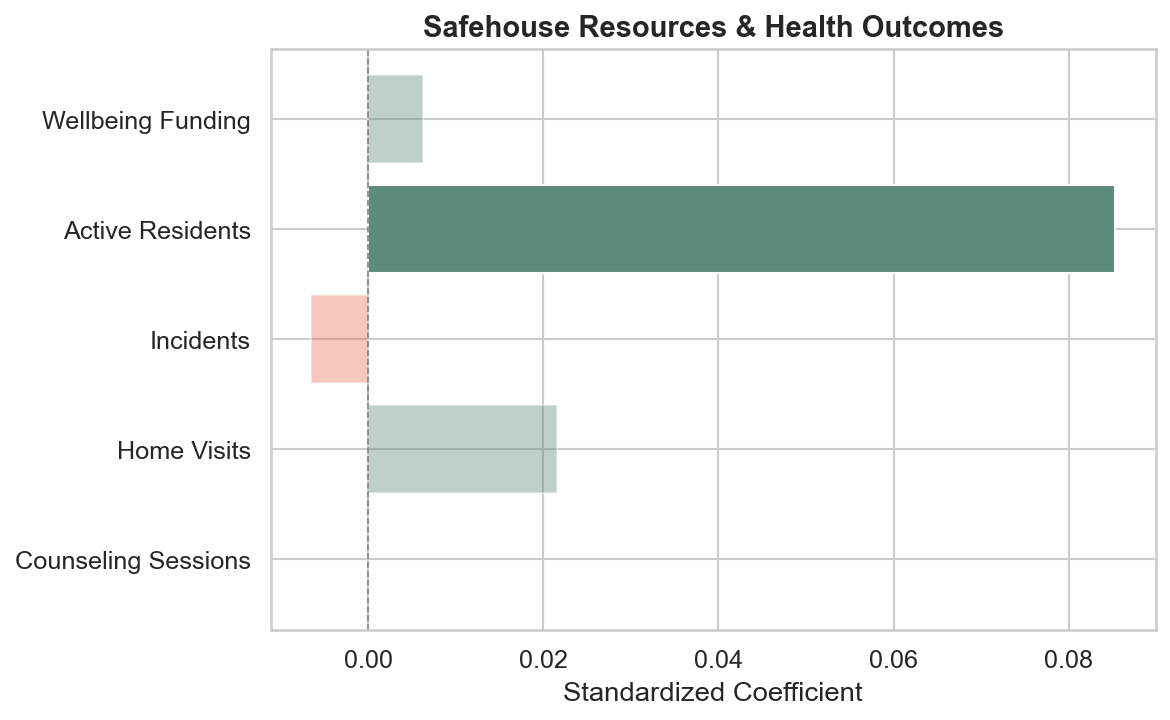


R-squared: 0.1648
Adj R-squared: 0.1479
Sample size: 253


,Feature,Coefficient,p-value,Significant
0,Counseling Sessions,-0.0001,0.9963,False
1,Home Visits,0.0216,0.2121,False
2,Incidents,-0.0065,0.6598,False
3,Active Residents,0.0853,0.0000,True
4,Wellbeing Funding,0.0062,0.6539,False


In [14]:
params = model.params.drop('const')
pvals = model.pvalues.drop('const')

labels = {
    'process_recording_count': 'Counseling Sessions',
    'home_visitation_count': 'Home Visits',
    'incident_count': 'Incidents',
    'active_residents': 'Active Residents',
    'wellbeing_funding': 'Wellbeing Funding'
}

results = pd.DataFrame({
    'Feature': [labels.get(f, f) for f in params.index],
    'Coefficient': params.values,
    'p-value': pvals.values,
    'Significant': pvals.values < 0.05
})

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#5B8C7A' if c > 0 else '#E8735A' for c in results['Coefficient']]
alphas = [1.0 if s else 0.4 for s in results['Significant']]
bars = ax.barh(results['Feature'], results['Coefficient'], color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Safehouse Resources & Health Outcomes', fontweight='bold', fontsize=14)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('12-safehouse-coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nR-squared: {model.rsquared:.4f}')
print(f'Adj R-squared: {model.rsquared_adj:.4f}')
print(f'Sample size: {len(y)}')
results.round(4)

## Section 4 — Interpretation & Recommendations

### Key Findings

- **Active resident count** is the strongest and only significant predictor.
  Safehouses with more active residents tend to have better health scores.
  This may reflect that well-functioning safehouses both attract residents and
  maintain their health.
- Other features (counseling sessions, incidents, wellbeing funding) show expected
  directions but do not reach statistical significance with this sample.

### Recommendations

1. Investigate what drives higher occupancy at successful safehouses.
2. Monitor incident rates as potential early warnings for declining wellbeing.
3. Continue investing in wellbeing programs, especially at lower-scoring locations.
4. Maintain consistent counseling and home visit frequency.

### Limitations

- Monthly safehouse-level data aggregates over individual residents.
- Active residents may be both cause and consequence of good health outcomes.
- Funding data may not capture all resource flows (e.g., volunteer hours, in-kind).
- The model explains about 16% of variation — many unmeasured factors contribute.